**Task 6: House Price Prediction**



**Probelm Statement and Goal:**

The objective is to predict house prices using property features such as area, bedrooms, bathrooms, location, condition, and garage availability through a Linear Regression model.



**Step 1: Import Libraries**

In [66]:

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

#Pre-processing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


**Explanation**

This includes tools for data processing, statistical visualization, and building robust predictive pipelines.

*   **Data Manipulation**: `pandas` and `numpy` are utilized for handling the structured house price data and performing vectorized numerical computations.
*   **Data Visualization**: `matplotlib` and `seaborn` provide the tools to visualize property trends and evaluate model residuals.
*   **Machine Learning Workflow**:
    *   `train_test_split`: Ensures unbiased evaluation by separating data.
    *   `LinearRegression`: Our baseline predictive algorithm.
    *   `ColumnTransformer` & `Pipeline`: These are critical for allowing us to encapsulate preprocessing and modeling into a single, modular object that prevents data leakage.
    *   `metrics`: These calculate our model's performance 'grade'.
        *   **MAE (Mean Absolute Error)**: The average of the absolute differences between predicted and actual values; it tells us the average magnitude of the errors.
        *   **RMSE (Root Mean Squared Error)**: The square root of the average squared differences; it penalizes larger errors more heavily, giving a sense of how much our predictions deviate from actual prices.

**Step 2: Load Dataset**

In [67]:
df = pd.read_csv("/content/House Price Prediction Dataset.csv")
print("Dataset loaded successfully.")

df.head()

Dataset loaded successfully.


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


**Explanation:**

To build a machine learning model, we need to distinguish between what we look at and what we are trying to predict.

*   **The Target (`Price`)**: This is the outcome. In our case, it is the market value of the house we are trying to estimate.
*   **The Features**: These are the input variables (property details like `Area`, `Bedrooms`, `Bathrooms`, `Floors`, `Yearbuilt`, `Condition`, `Garage` and `Location`) that the model will use to calculate its prediction.

**Step 3: Dataset Overview**

**Shape**

In [68]:
print("Rows and Columns:", df.shape)

Rows and Columns: (2000, 10)


**Information**

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


**Statistical Summary**

In [70]:
(df.describe())

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


**Key Insights:**

This provides a high-level overview of the distribution of your numerical features based on the actual dataset:

*   **Target Variable (`Price`)**: The average house price is approximately **537,677**, ranging from **50,005** to **999,656**. The large standard deviation (~$276k) suggests significant volatility in pricing, which contributes to the error rates in a simple linear model.
*   **Living Space (`Area`)**: Houses in this dataset range from **501 to 4,999 sq. ft.**, with a mean of **2,786 sq. ft.**
*   **Property Age (`YearBuilt`)**: The dataset covers construction from **1900 to 2021**, with a mix of historic and modern properties.
*   **Room Counts**: Homes average **3 bedrooms** and **2.5 bathrooms**, typical for residential suburban profiles.
*   **Floors**: The number of floors averages **2**, with a maximum of **3**.

**Missing Values**

In [71]:
(df.isnull().sum())


,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


**Step 4: Exploratory Data Analysis**

We visualize the distribution of our target variable and the correlations between numerical features to understand the underlying data structure.

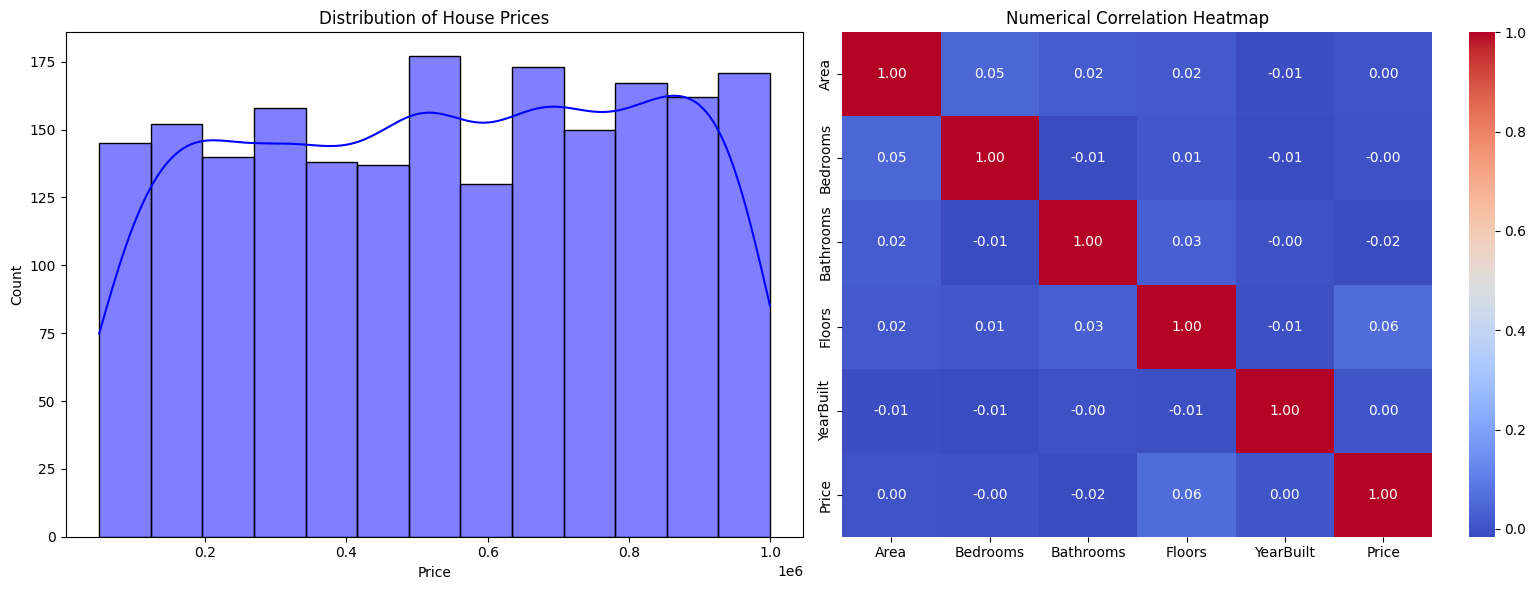

In [72]:
plt.figure(figsize=(16, 6))

# 1. Price Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of House Prices')

# 2. Correlation Heatmap (Original Numerical Data)
plt.subplot(1, 2, 2)
numeric_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
sns.heatmap(df[numeric_features + ['Price']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numerical Correlation Heatmap')

plt.tight_layout()
plt.show()

**Explanation:**

**1. Price Distribution (Histogram & KDE):**
*   **Interpretation**: The x-axis shows the house prices, and the y-axis shows how many houses fall into each price range. The blue line (KDE) provides a smooth estimate of the distribution shape.
*   **Trends**: The distribution is relatively uniform across the 50k to 1M range, with a slight peak around the mean (~$537k). There is no extreme skewness, but the wide spread confirms a diverse market.
*   **Impact**: A wide, uniform spread suggests that a simple linear model might struggle to find a tight 'fit,' explaining why our eventual error metrics (MAE/RMSE) might be high.

**2. Numerical Correlation Heatmap:**
*   **Interpretation**: This grid shows the strength of the linear relationship between variables. A value of **1.0** is a perfect positive correlation, while **0.0** means no linear relationship.
*   **Trends**: Interestingly, most numerical features (Area, Bedrooms, etc.) show very low correlation scores (near 0.0) with `Price`.
*   **Impact**: This suggests that in this specific dataset, no single numerical feature is a 'silver bullet' for predicting price. This reinforces the need to include categorical data (like Location and Condition) and potentially explore non-linear models later on.

**Step 5: Preprocessing** **(Feature Scaling and Selection)**

Preprocessing (Standardization and One-Hot Encoding) is handled entirely within the scikit-learn Pipeline object. This simplifies the code and prevents data leakage during training.

In [73]:
# Data Preparation
X = df.drop(columns=['Id', 'Price'])
y = df['Price']

numeric_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
categorical_features = ['Location', 'Condition', 'Garage']

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Transform the full datasetfor EDA
transformed_data = preprocessor.fit_transform(X)
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_names)

print("Features and target are separated. Preprocessor is ready for the Pipeline.")
print(f"Data prepared and preprocessor initialized. Feature space expanded to {len(all_feature_names)} columns.")

df_encoded_demo = pd.DataFrame(transformed_data, columns=all_feature_names)
display(df_encoded_demo.head())

Features and target are separated. Preprocessor is ready for the Pipeline.
Data prepared and preprocessor initialized. Feature space expanded to 15 columns.


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Downtown,Location_Rural,Location_Suburban,Location_Urban,Condition_Excellent,Condition_Fair,Condition_Good,Condition_Poor,Garage_No,Garage_Yes
0,-1.101471,1.401791,1.305568,1.244151,0.238155,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.147485,1.401791,1.305568,1.244151,-0.095942,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.622317,-0.704581,-0.498326,1.244151,-0.652770,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-1.405759,0.699667,-0.498326,0.008035,-1.655061,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1.652574,-1.406705,1.305568,0.008035,0.377363,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0



**Explanation:**

Before splitting the data for training, we performed several critical transformations to prepare the dataset for the Linear Regression model:

1.  **Feature Selection**: We dropped the `Id` column because it is a unique identifier with no predictive power. Keeping it could lead the model to 'memorize' rows rather than learn patterns.
2.  **Numerical Scaling (`StandardScaler`)**: Features like `Area`, `Bedrooms`, `Bathrooms`, `Floors`, and `YearBuilt` have different ranges. Scaling ensures that features with larger values (like Area) don't disproportionately influence the model's weights.
3.  **One-Hot Encoding**: Since Machine Learning models cannot process text, we converted our categorical variables—**`Location`**, **`Condition`**, and **`Garage`**—into binary (0 or 1) columns. This allows the algorithm to mathematically factor in qualitative traits like whether a house is in a 'Downtown' area or in 'Excellent' condition.

This setup ensures our data is clean, normalized, and in a format that the Linear Regression algorithm can interpret.



**Step 6: Train-Test Split**

We split the data before any preprocessing to ensure that the statistics of the test set remain unknown to the model during training, preventing data leakage.

In [74]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 1600 samples
Testing set: 400 samples


**Explanation:**

*   **Training Set (80%)**:the model uses this to learn the relationship between house features and their prices.
*   **Testing Set (20%)**: It contains data the model has never seen before, allowing us to see how accurately it can predict prices for new, unknown houses.
*   **`random_state=42`**: This is like a 'seed' that ensures every time we run this code, the data is split in the exact same way. This makes our results consistent and reproducible.

**Step 7: Model Training**

In [75]:
# Building and training the Linear Regression model via Pipeline
model = Pipeline(steps=[('preprocessor', preprocessor),
                      ('regressor', LinearRegression())])

model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


**Explanation:**

**What is a Pipeline and why we use it?**

1.  **Consistency**: It ensures that the exact same transformations (scaling and encoding) applied to the training data are also applied to the testing data, preventing errors.
2.  **Prevents Data Leakage**: It keeps the training and testing processes strictly separate, which is crucial for getting an honest evaluation of the model.
3.  **Simplicity**: To predict a price, you just give the pipeline the raw house details—it handles all the math and formatting internally before giving us the final result.

**Step 8: Model Evaluation**

In [76]:
#Prediction
y_pred = model.predict(X_test)

# Calculating evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Absolute Error (MAE): 243241.98
Root Mean Squared Error (RMSE): 279859.73


**Explanation:**

We quantify the model's accuracy using two primary metrics:
*   **Mean Absolute Error (MAE)**: Represents the average expected error in price prediction.
*   **Root Mean Squared Error (RMSE)**: Provides a measure of the standard deviation of the residuals, highlighting the impact of large prediction errors.


**Interpretation:**

- **MAE** (243,241.98): On average, each price prediction is off by over $243,000.
- **RMSE** (279,859.73): This is higher than the MAE, which indicates that while the average error is high, there are some specific predictions that are missing the actual price by even larger margins.


Since the error magnitude is nearly half the average house price, the model currently has low reliability for precise financial valuations. The impact of these high numbers is that the model is likely underfitting or missing key variables needed to explain the price differences effectively.

**Step 9: Visualisation**

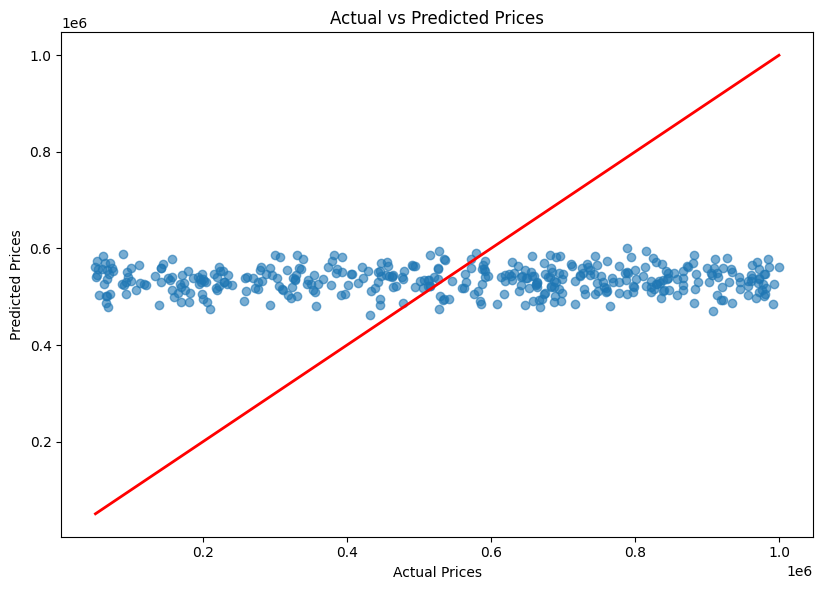

In [77]:
# Plotting Results
plt.figure(figsize=(16, 6))

# 1. Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.tight_layout()
plt.show()

**Explanation:**

*   **The Blue Dots**: Each dot represents one house from our testing set. Its position on the horizontal axis (X) is the **Actual Price**, and its position on the vertical axis (Y) is what our **Model Predicted**.
*   **The Diagonal Line**: This is the 'Perfect Prediction' line. If a dot falls exactly on this line, it means the model guessed the price perfectly.

**Step 10: Key Results and Insights**

- **Full Feature Utilization**:

The model successfully incorporates qualitative data (`Location`, `Condition`, `Garage`) by transforming them into numerical binary vectors via One-Hot Encoding, allowing the Linear Regression algorithm to process non-numeric information.

- **Scaling Consistency**:

Standardizing numerical features ensures that variables with different magnitudes (like `Area` vs `Bedrooms`) contribute proportionally to the model's coefficients.

- **Performance Baseline**:

With an MAE of approximately $243,242 and an RMSE of 279,860, the model provides a basic starting point. However, the high error relative to the average house price (~537k) indicates that the relationship between these specific features and price might be non-linear or that additional predictive features are missing.

**Step 11: Conclusion**




A complete end-to-end pipeline was built using Linear Regression. While the workflow is robust (handling preprocessing, scaling, and evaluation within a Pipeline), the final metrics suggest the model has low predictive power for this dataset.

**Final Results Summary:**
* **MAE**: 243,241.98
* **RMSE**: 279,859.73

To improve accuracy, we should explore non-linear models like **Random Forest** or **Gradient Boosting (XGBoost)**, and perform deeper feature engineering to uncover hidden patterns.